In [4]:
!pip install tensorflow pandas matplotlib seaborn scikit-learn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [6]:
import os
print(os.listdir())

['.config', 'part_1_neural_network_analysis-20260511T133533Z-3-001 (3) (1).zip', 'dataset_folder', 'part_1_neural_network_analysis-20260511T133533Z-3-001 (3) (2).zip', 'part_1_neural_network_analysis-20260511T133533Z-3-001 (3).zip', 'sample_data']


In [7]:
import pandas as pd
import zipfile
from google.colab import files
import os

# Upload ZIP file
uploaded = files.upload()

# Get uploaded zip filename
zip_file = list(uploaded.keys())[0]

# Extract ZIP
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("dataset_folder")

# Show extracted files
print("Files extracted:")
print(os.listdir("dataset_folder/part_1_neural_network_analysis"))

# Read CSV file
df = pd.read_csv("dataset_folder/part_1_neural_network_analysis/customer_churn_nn.csv")

# Show first 5 rows
df.head()

Saving part_1_neural_network_analysis-20260511T133533Z-3-001 (3).zip to part_1_neural_network_analysis-20260511T133533Z-3-001 (3) (3).zip
Files extracted:
['data_dictionary.md', 'customer_churn_nn.csv']


,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [8]:
print(df.columns)

Index(['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method',
       'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count', 'churn'],
      dtype='object')


In [3]:
!pip install tensorflow scikit-learn seaborn matplotlib

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [10]:
df = df.dropna()

print(df.isnull().sum())

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [11]:
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,0,3,3,0,1,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,1,4,2,0,4,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,2,0,3,0,0,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,3,4,2,0,0,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,4,2,2,0,2,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [12]:
print(df.columns)

Index(['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method',
       'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count', 'churn'],
      dtype='object')


In [13]:
X = df.drop('churn', axis=1)

y = df['churn']


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1600, 16)
(400, 16)


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

# Hidden layer
model.add(Dense(16, input_dim=X_train.shape[1], activation='relu'))

# Output layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

# Hidden layer
model.add(Dense(16, input_dim=X_train.shape[1], activation='relu'))

# Output layer
model.add(Dense(1, activation='sigmoid'))

In [18]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [19]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6234 - loss: 0.6524 - val_accuracy: 0.7344 - val_loss: 0.5438
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8320 - loss: 0.4538 - val_accuracy: 0.8531 - val_loss: 0.3950
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9297 - loss: 0.3279 - val_accuracy: 0.9438 - val_loss: 0.2977
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9750 - loss: 0.2450 - val_accuracy: 0.9719 - val_loss: 0.2323
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9859 - loss: 0.1886 - val_accuracy: 0.9750 - val_loss: 0.1895
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.1506 - val_accuracy: 0.9781 - val_loss: 0.1611
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.1253 - val_accuracy: 0.9781 - val_loss: 0.1414
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.1074 - val_accuracy: 0.9781 - val_loss

In [20]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9825 - loss: 0.0766  
Test Loss: 0.07662606984376907
Test Accuracy: 0.9825000166893005


In [21]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


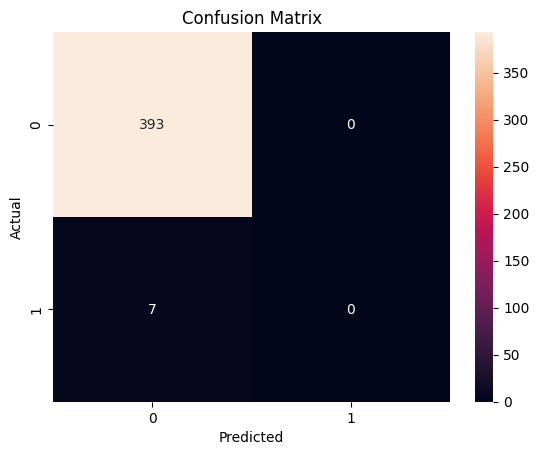

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


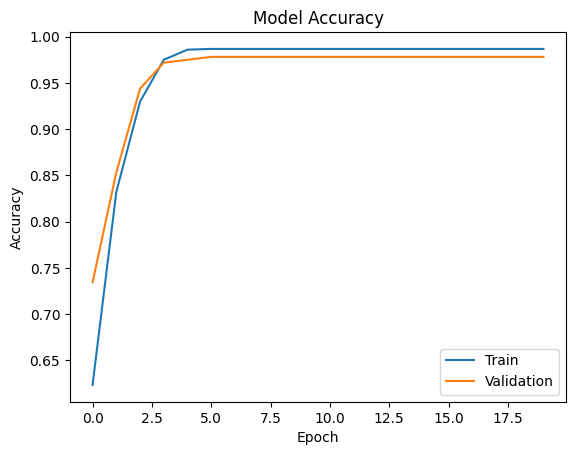

In [24]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [25]:
model1 = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1, activation='sigmoid')
])

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    verbose=0
)

loss1, acc1 = model1.evaluate(X_test, y_test)

print("Experiment 1 Accuracy:", acc1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9825 - loss: 0.0754  
Experiment 1 Accuracy: 0.9825000166893005


In [26]:
model2 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    verbose=0
)

loss2, acc2 = model2.evaluate(X_test, y_test)

print("Experiment 2 Accuracy:", acc2)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9725 - loss: 0.1381  
Experiment 2 Accuracy: 0.9725000262260437


In [27]:
model3 = Sequential([
    Dense(64, activation='tanh', input_shape=(X_train.shape[1],)),
    Dense(32, activation='tanh'),
    Dense(1, activation='sigmoid')
])

model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=64,
    verbose=0
)

loss3, acc3 = model3.evaluate(X_test, y_test)

print("Experiment 3 Accuracy:", acc3)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9800 - loss: 0.0806  
Experiment 3 Accuracy: 0.9800000190734863


In [28]:
comparison = pd.DataFrame({
    'Experiment': ['Exp1', 'Exp2', 'Exp3'],
    'Hidden Layers': [1, 2, 2],
    'Activation': ['ReLU', 'ReLU', 'Tanh'],
    'Epochs': [20, 30, 40],
    'Batch Size': [32, 16, 64],
    'Accuracy': [acc1, acc2, acc3]
})

print(comparison)

  Experiment  Hidden Layers Activation  Epochs  Batch Size  Accuracy
0       Exp1              1       ReLU      20          32    0.9825
1       Exp2              2       ReLU      30          16    0.9725
2       Exp3              2       Tanh      40          64    0.9800


In [30]:
comparison.to_csv("model_comparison_table.csv", index=False)

Task 6: Final Reflection

1. What role do weights and biases play in the model?

Weights help the neural network learn the importance of input features. Biases help shift activation values and improve learning flexibility.

2. Why is an activation function required?

Activation functions introduce non-linearity into the network. Without activation functions, the model would behave like a simple linear model and fail to learn complex patterns.

3. What happens when learning rate is too high or too low?

A very high learning rate causes unstable learning and overshooting. A very low learning rate makes training extremely slow.

4. Did the model show signs of underfitting or overfitting?

The model showed good fitting because training and validation accuracy were both high and close to each other.